# Data Drift Analysis

The selected CatBoost model demonstrated stable performance on the
validation and calibration datasets, but its performance deteriorated
substantially on the external test dataset.

Calibration:
- ROC-AUC = 0.830
- PR-AUC = 0.488

External test:
- ROC-AUC = 0.630
- PR-AUC = 0.022

Additionally, the positive class rate changed from approximately 11%
in the development dataset to approximately 0.44% in the external test set.

The purpose of this notebook is to investigate whether the performance
degradation can be explained by data drift.

In [1]:
import numpy as np
import pandas as pd
import numpy as pn
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import ks_2samp

import joblib

In [2]:
# Constants
RANDOM_SEED = 42
PATH_TO_TRAIN_DATA = '../data/train-FIN_ANA_DATA.xls'
PATH_TO_TEST_DATA = '../data/test-FIN_ANA_DATA.xls'

In [3]:
df_train = pd.read_excel(PATH_TO_TRAIN_DATA)
df_test= pd.read_excel(PATH_TO_TEST_DATA)

## Target Distribution shift

In [4]:
# unique values in the target variable
df_test['QUALITY_OF_LOAN'].value_counts()

QUALITY_OF_LOAN
G     4286
B       19
DF       4
SS       1
Name: count, dtype: int64

In [5]:
mapping = {
    'G': 0,
    'B': 1
}

# ['G', 'B']
known_classes = df_train['QUALITY_OF_LOAN'].unique()

df_test = df_test[
    df_test['QUALITY_OF_LOAN'].isin(known_classes)
].copy()

df_train['QUALITY_OF_LOAN'] = (
    df_train['QUALITY_OF_LOAN']
    .map(mapping)
)

df_test['QUALITY_OF_LOAN'] = (
    df_test['QUALITY_OF_LOAN']
    .map(mapping)
)

5 objects with "strange" target variables (DF and SS) were removed

In [6]:
def target_stats(name, y):
    return {
        'dataset': name,
        'n': len(y),
        'positive': y.sum(),
        'positive_rate': y.mean()
    }

target_distribution = pd.DataFrame([
    target_stats(
        'train',
        df_train['QUALITY_OF_LOAN']
    ),
    target_stats(
        'test',
        df_test['QUALITY_OF_LOAN']
    )
])

target_distribution

,dataset,n,positive,positive_rate
0,train,37408,4154,0.111046
1,test,4305,19,0.004413


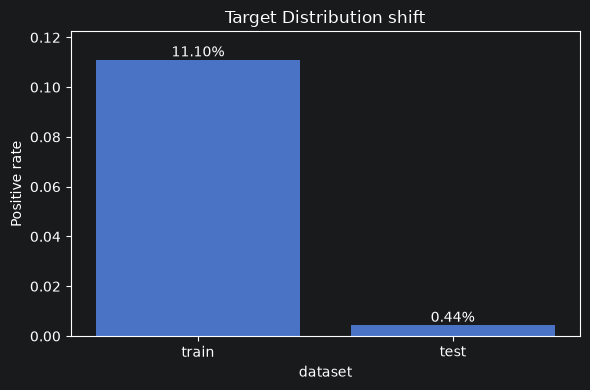

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_distribution, x='dataset', y='positive_rate')
ax.set_title('Target Distribution shift')
ax.bar_label(ax.containers[0],
             labels=[f'{val * 100:.2f}%' for val in target_distribution['positive_rate']])
ax.set_ylim(top=ax.get_ylim()[1] * 1.05)
ax.set_ylabel('Positive rate')
plt.tight_layout()
plt.show()

The positive class rate decreases from 11.1% in the train dataset
to 0.44% in the test dataset

This indicates a substantial target shift

## Missing-value drift

In [8]:
categorial_features = ['INF_MARITAL_STATUS', 'INF_GENDER',
                       'COMPENSATION_CHARGED', 'CLIENT_TYPE',
                       'REPAY_MODE']
numeric_features = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
                    'INSTALL_SIZE', 'DUE_PAYMENT']

feature_columns = numeric_features + categorial_features

missing_train = df_train[feature_columns].isna().mean()
missing_test = df_test[feature_columns].isna().mean()

missing_df = pd.DataFrame({
    'train_missing_rate': missing_train,
    'test_missing_rate': missing_test
})

missing_df['diff'] = missing_df['test_missing_rate'] - missing_df['train_missing_rate']
missing_df.sort_values(by='diff', ascending=False)

,train_missing_rate,test_missing_rate,diff
CLIENT_TYPE,0.002753,0.018351,0.015597
INVESTMENT_TOTAL,0.000000,0.000000,0.000000
ACCCURRENTBALANCE,0.000000,0.000000,0.000000
REPAY_MODE,0.000000,0.000000,0.000000
DUE_PAYMENT,0.000000,0.000000,0.000000
COMPENSATION_CHARGED,0.000053,0.000000,-0.000053
INF_MARITAL_STATUS,0.000053,0.000000,-0.000053
INF_GENDER,0.000053,0.000000,-0.000053
INSTALL_SIZE,0.022402,0.000232,-0.022169


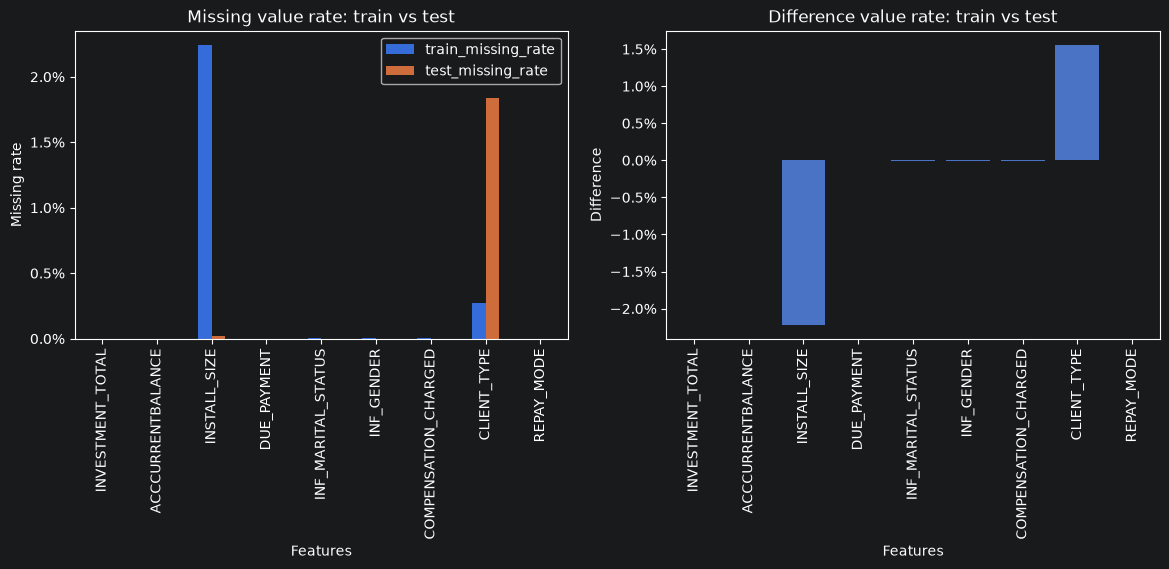

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
(ax1, ax2) = axes.flatten()

missing_df[
    ['train_missing_rate', 'test_missing_rate']
].plot(
    kind='bar',
    ax=ax1
)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
ax1.set_title('Missing value rate: train vs test')
ax1.set_xlabel('Features')
ax1.set_ylabel('Missing rate')


sns.barplot(data=missing_df, x=missing_df.index, y='diff', ax=ax2)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
ax2.set_title('Difference value rate: train vs test')
ax2.set_xlabel('Features')
ax2.set_ylabel('Difference')
ax2.tick_params(axis='x', rotation=90)
plt.show()

## Numeric feature drift

In [10]:
# Kolmogorov-Smirnov statistics

ks_results = []

for feature in numeric_features:

    train_values = (df_train[feature].dropna())
    test_values = (df_test[feature].dropna())

    ks_stat, p_value = ks_2samp(train_values,test_values)

    ks_results.append({
        'feature': feature,
        'ks_statistic': ks_stat,
        'p_value': p_value
    })

pd.DataFrame(ks_results)

,feature,ks_statistic,p_value
0,INVESTMENT_TOTAL,0.129970,2.523323e-57
1,ACCCURRENTBALANCE,0.074546,4.179119e-19
2,INSTALL_SIZE,0.064905,1.509826e-14
3,DUE_PAYMENT,0.020307,8.167324e-02


## Categorical feature drift

INF_MARITAL_STATUS


,train,test
INF_MARITAL_STATUS,,
M,0.946642,0.945877
U,0.052475,0.053891
O,0.000829,0.000232
missing,0.000053,0.000000


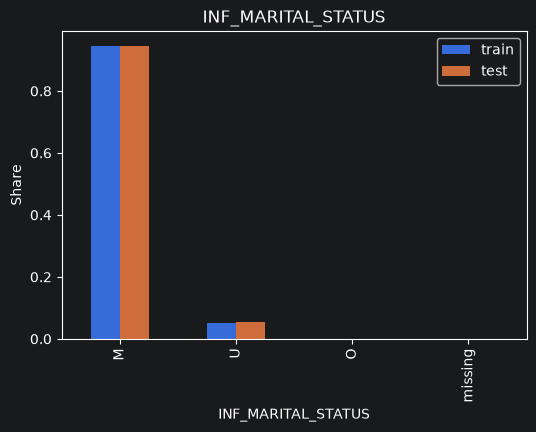

INF_GENDER


,train,test
INF_GENDER,,
M,0.741980,0.847851
F,0.257913,0.152149
missing,0.000053,0.000000
O,0.000053,0.000000


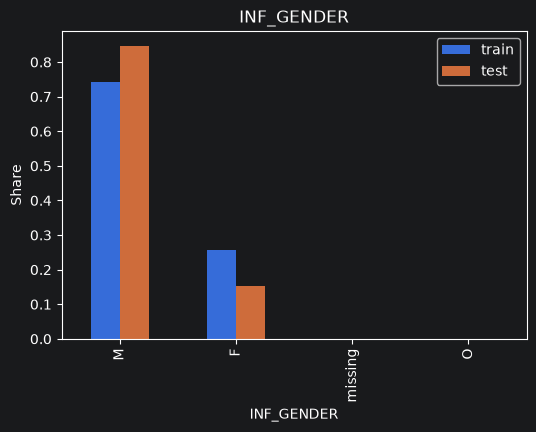

COMPENSATION_CHARGED


,train,test
COMPENSATION_CHARGED,,
N,0.553277,0.911731
Y,0.446669,0.088269
missing,0.000053,0.000000


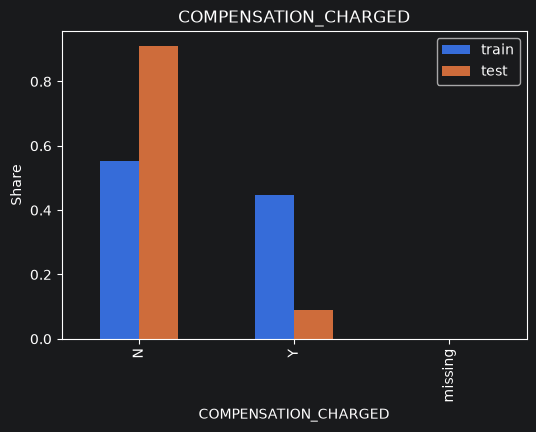

CLIENT_TYPE


,train,test
CLIENT_TYPE,,
Rural,0.698888,0.733566
Semi-urban,0.227999,0.000000
Urban,0.070279,0.184669
missing,0.002753,0.018351
0,0.000080,0.000000
Semi-Urban,0.000000,0.063415


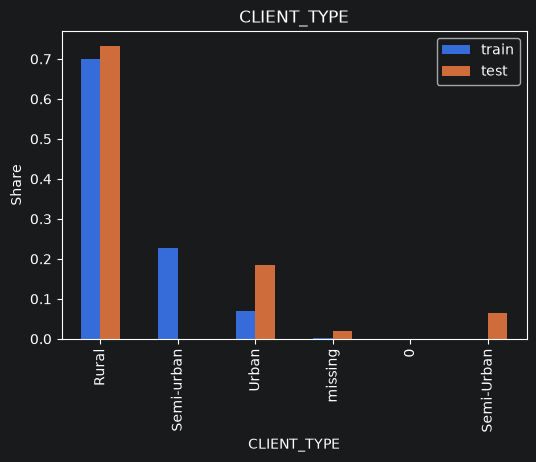

REPAY_MODE


,train,test
REPAY_MODE,,
N,0.844285,0.872706
I,0.155715,0.127294


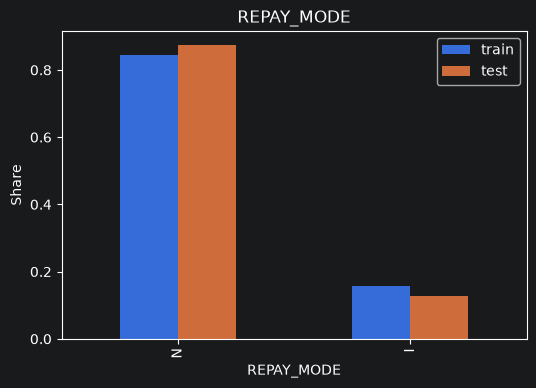

In [11]:
for feature in categorial_features:

    train_values = (df_train[feature].fillna('missing').
                    astype(str).value_counts(normalize=True))
    test_values = (df_test[feature].fillna('missing').
                   astype(str).value_counts(normalize=True))

    comparison = pd.concat([
        train_values.rename('train'),
        test_values.rename('test')],
        axis=1
    ).fillna(0)

    print(feature)
    display(comparison)

    comparison.plot(kind='bar', figsize=(6,4))
    plt.ylabel('Share')
    plt.title(feature)
    plt.show()

## PSI

$$\text{PSI} = \sum \left( \text{Actual}\% - \text{Expected}\% \right) \times \ln\left(\frac{\text{Actual}\%}{\text{Expected}\%}\right)$$

In [12]:
def calculate_psi_numeric(
        expected,
        actual,
        bins=10,
        eps=1e-6
):
    expected = expected.dropna()
    actual = actual.dropna()

    _, bin_edges = pd.qcut(
        expected, q=bins, retbins=True, duplicates='drop'
    )

    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    expected_bins = pd.cut(
        expected, bins=bin_edges
    )

    actual_bins = pd.cut(
        actual, bins=bin_edges
    )

    expected_dist = expected_bins.value_counts(normalize=True)
    actual_dist = actual_bins.value_counts(normalize=True)

    expected_dist = expected_dist.clip(lower=eps)
    actual_dist = actual_dist.clip(lower=eps)

    psi = ((actual_dist - expected_dist) * np.log(actual_dist / expected_dist)).sum()
    return psi

In [18]:
psi_numeric = []

for feature in numeric_features:

    psi_numeric.append({
        'feature': feature,
        'psi': calculate_psi_numeric(
            df_train[feature],
            df_test[feature]
        )
    })

psi_numeric = pd.DataFrame(psi_numeric)

psi_numeric.sort_values(
    'psi',
    ascending=False
)

,feature,psi
0,INVESTMENT_TOTAL,0.187995
2,INSTALL_SIZE,0.068393
1,ACCCURRENTBALANCE,0.061354
3,DUE_PAYMENT,0.001419


In [37]:
def calculate_psi_categorical(
        expected,
        actual,
        eps=1e-6
):
        expected = expected.fillna('missing').astype(str).str.lower()
        actual = actual.fillna('missing').astype(str).str.lower()

        expected_dist = expected.value_counts(normalize=True)
        actual_dist = actual.value_counts(normalize=True)

        all_categories = expected_dist.index.union(actual_dist.index)

        expected_dist = expected_dist.reindex(
            all_categories,
            fill_value=0
        )

        actual_dist = actual_dist.reindex(
            all_categories,
            fill_value=0
        )

        expected_dist = expected_dist.clip(lower=eps)
        actual_dist = actual_dist.clip(lower=eps)

        psi_values = ((actual_dist - expected_dist) * np.log(actual_dist / expected_dist))

        details = pd.DataFrame({
            'expected_share' : expected_dist,
            'actual_share': actual_dist,
            'psi_component': round(psi_values, 4)
        })

        return psi_values.sum(), details


In [38]:
for feature in categorial_features:
    psi, details = calculate_psi_categorical(
        df_train[feature],
        df_test[feature]
    )
    print(f'{feature} PSI: {psi:.4f}')
    display(details)

INF_MARITAL_STATUS PSI: 0.0010


,expected_share,actual_share,psi_component
INF_MARITAL_STATUS,,,
m,0.946642,0.945877,0.0000
missing,0.000053,0.000001,0.0002
o,0.000829,0.000232,0.0008
u,0.052475,0.053891,0.0000


INF_GENDER PSI: 0.0704


,expected_share,actual_share,psi_component
INF_GENDER,,,
f,0.257913,0.152149,0.0558
m,0.741980,0.847851,0.0141
missing,0.000053,0.000001,0.0002
o,0.000053,0.000001,0.0002


COMPENSATION_CHARGED PSI: 0.7604


,expected_share,actual_share,psi_component
COMPENSATION_CHARGED,,,
missing,0.000053,0.000001,0.0002
n,0.553277,0.911731,0.1790
y,0.446669,0.088269,0.5811


CLIENT_TYPE PSI: 0.3527


,expected_share,actual_share,psi_component
CLIENT_TYPE,,,
0,0.000080,0.000001,0.0003
missing,0.002753,0.018351,0.0296
rural,0.698888,0.733566,0.0017
semi-urban,0.227999,0.063415,0.2106
urban,0.070279,0.184669,0.1105


REPAY_MODE PSI: 0.0067


,expected_share,actual_share,psi_component
REPAY_MODE,,,
n,0.844285,0.872706,0.0009
i,0.155715,0.127294,0.0057


## Prediction Drift